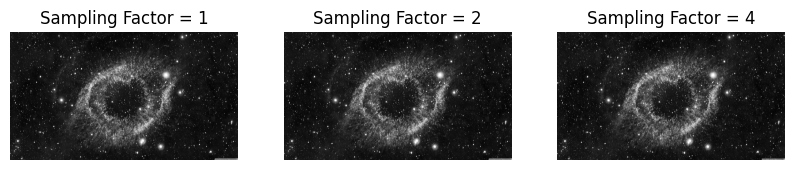

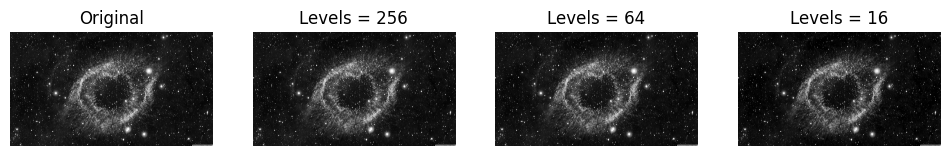

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image
image = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

if image is None:
    raise ValueError("Image not found")

# Function for sampling
def sampling(img, factor):
    return img[::factor, ::factor]

# Function for quantization
def quantization(img, levels):
    img_norm = img / 255.0
    img_quant = np.floor(img_norm * levels) / levels
    return (img_quant * 255).astype(np.uint8)

# Sampling factors and quantization levels
sampling_factors = [1, 2, 4]
quant_levels = [256, 64, 16]

# Display sampling results
plt.figure(figsize=(10, 4))
for i, f in enumerate(sampling_factors):
    sampled_img = sampling(image, f)
    sampled_img = cv2.resize(sampled_img, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
    plt.subplot(1, 3, i+1)
    plt.imshow(sampled_img, cmap='gray')
    plt.title(f'Sampling Factor = {f}')
    plt.axis('off')
plt.show()

# Display quantization results with original image
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

for i, q in enumerate(quant_levels):
    quant_img = quantization(image, q)
    plt.subplot(1, 4, i+2)
    plt.imshow(quant_img, cmap='gray')
    plt.title(f'Levels = {q}')
    plt.axis('off')

plt.show()